# Create a dataset for EVASPA with landsat8 and ECOSTRESS data 

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
from etdataset.api import create_dataset
from etdataset.plot import plot_images
from etdataset.writer import write_dataset, export_matlab

### Inputs 
* Landsat product path
* ECOSTRESS product path

In [4]:
# Product paths
data_path = os.environ["DATA_PATH"]
ls8_path = os.path.join(data_path, "Landsat8","LC09_L2SP_205050_20230327_20230329_02_T1")
eco_path = os.path.join(
    data_path, "ECOSTRESS","ECOv002_L2T_LSTE_26870_001_28PCA_20230402T115902_0710_01"
)

In [5]:
# Directory path for results
output_dir = "out"
os.makedirs(output_dir, exist_ok=True)

### Create dataset

In [6]:
# To take or not into account mask, use option use_mask
ds = create_dataset(vis_path=ls8_path, tir_path=eco_path, use_mask=True)

24-01-25 22:31:35 :: INFO :: Use MGRS tile from TIR product


(<Figure size 1500x1500 with 11 Axes>,
 array([[<Axes: title={'center': 'RGB'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LST'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'Emissivity'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'Albedo'}, xlabel='x', ylabel='y'>],
        [<Axes: title={'center': 'NDVI'}, xlabel='x', ylabel='y'>,
         <Axes: title={'center': 'LAI'}, xlabel='x', ylabel='y'>]],
       dtype=object))

/home/sarrazine/pyenvs/cesbio/lib/python3.10/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


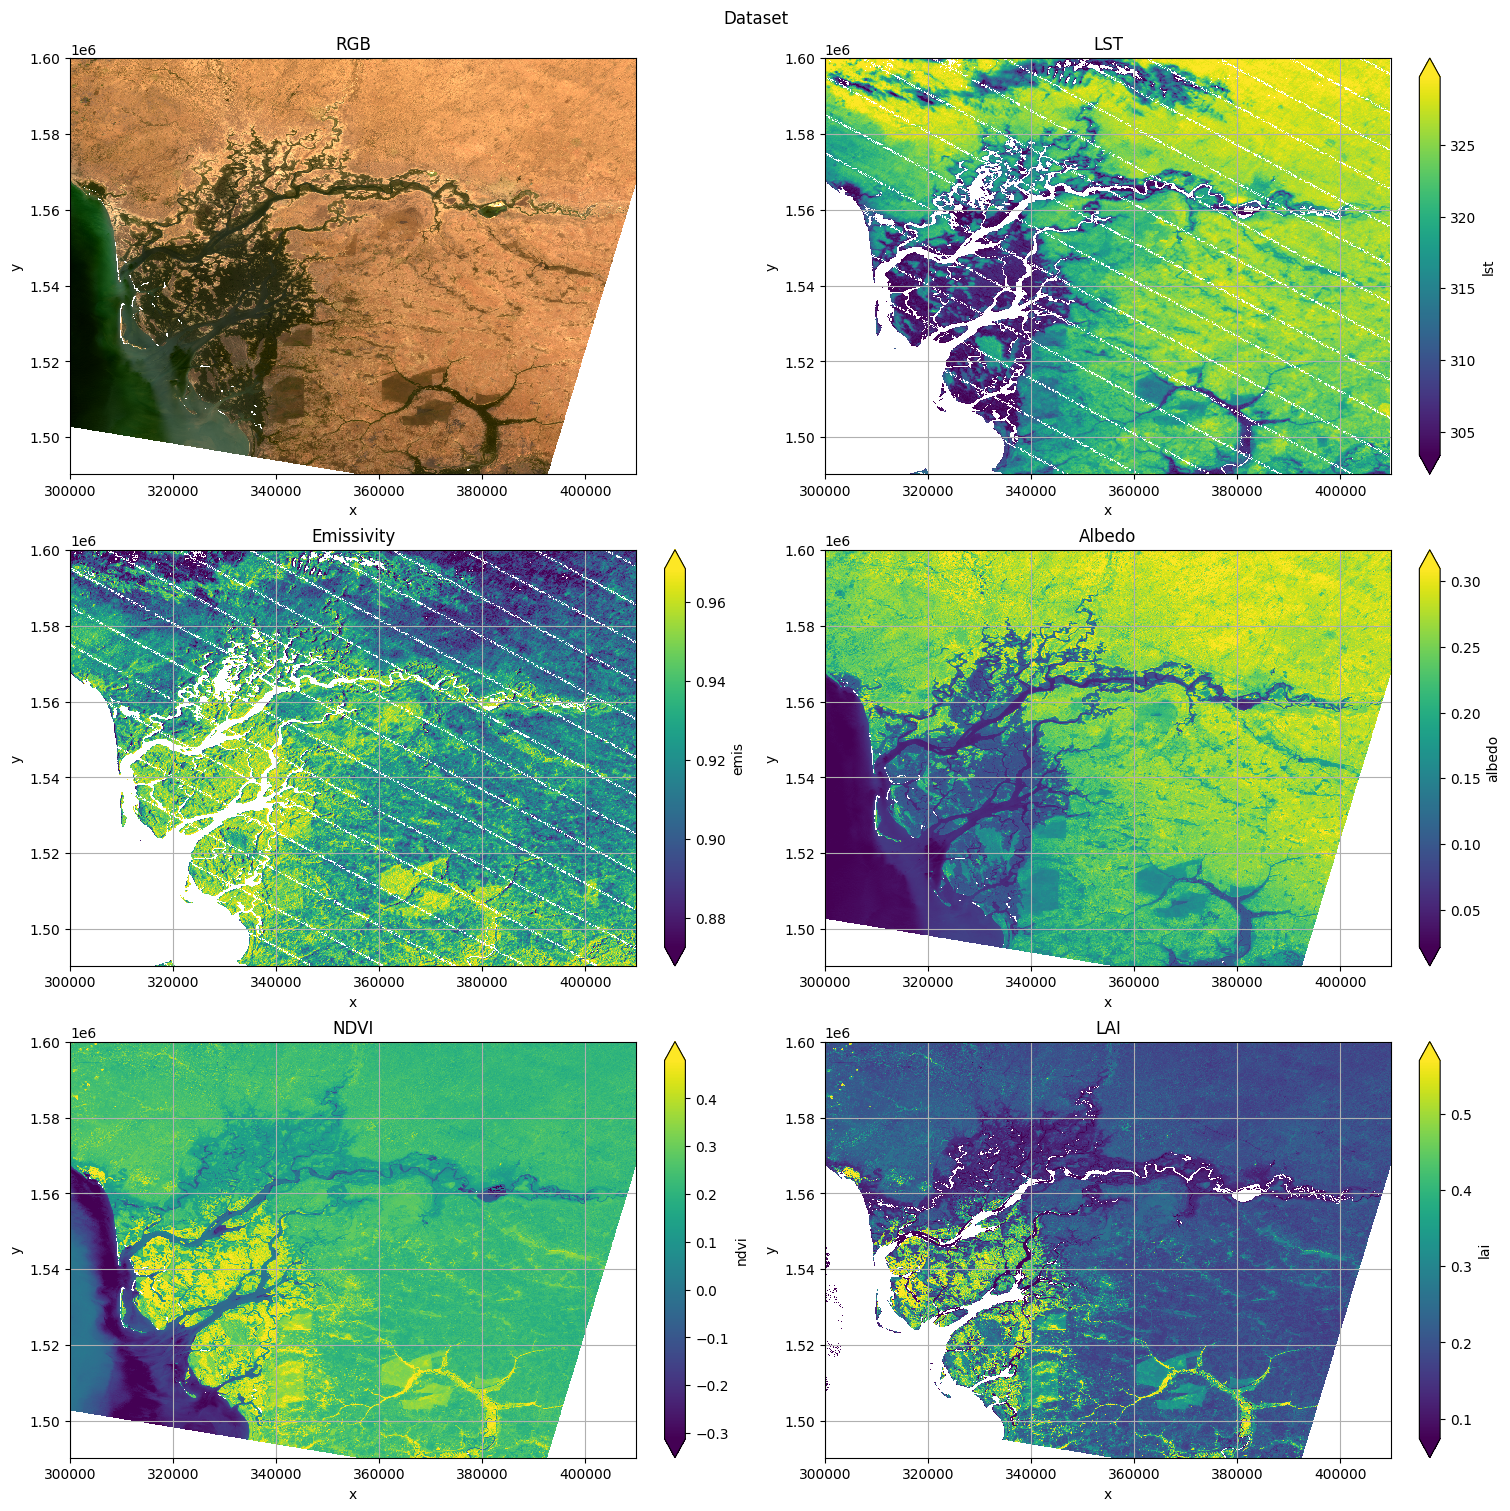

In [7]:
plot_images(ds)

### Write dataset

In [8]:
# Tif format
write_dataset(ds, directory=output_dir)

In [9]:
# Matlab
export_matlab(ds, directory=output_dir)